# Final Results: Seeds 42, 43, and 44

Experiment 1, original clean models, 1% poison rate, conservative trigger features,
eight selectors, Random and Distribution-based sampling, EMBER 2018 and EMBER 2024 Win64.
This notebook is independent of the previous notebooks. It exports deletion-safe scalar
snapshots and compares individual runs with three-run means and sample standard deviations
(`ddof=1`). The ASR/evasion column retains the existing result catalog definition.
Poison recall is reported separately for each sanitizer, not averaged across sanitizers.


In [1]:
from pathlib import Path
import hashlib
import json
import os
import sys
import itertools
import numpy as np
import pandas as pd
from IPython.display import display, FileLink

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))
os.environ.setdefault('MPLCONFIGDIR', str(PROJECT_ROOT / 'build' / 'matplotlib'))
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
from src.analysis.result_catalog import load_attack_summaries, load_detector_metrics

RESULTS_ROOT = PROJECT_ROOT / 'results' / 'experiment 1'
OUT = RESULTS_ROOT / 'tables' / 'final_result_seed42_seed43_seed44' / 'poison_1p'
PLOTS = RESULTS_ROOT / 'plots' / 'final_result_seed42_seed43_seed44' / 'poison_1p'
OUT.mkdir(parents=True, exist_ok=True)
PLOTS.mkdir(parents=True, exist_ok=True)
SEEDS = [42, 43, 44]
SAMPLINGS = ['random', 'distribution_based_distance']
SELECTORS = ['min_population_new', 'argmin_Nv_sum_abs_shap', 'combined_shap',
             'low_shap_signed', 'frequency_bounded_signed_shap', 'corr_count_abs_shap',
             'benign_prototype', 'quantile_95']
LABELS = dict(zip(SELECTORS, ['MinPopulation*', 'CountAbsSHAP*', 'CombinedSHAP*',
                            'LowSignedSHAP', 'FreqBoundedSigned', 'CorrCountAbsSHAP',
                            'BenignPrototype', 'Quantile95']))
DATASETS = ['EMBER 2018', 'EMBER 2024 Win64']
SAMPLING_LABELS = dict(zip(SAMPLINGS, ['Random', 'Distribution-based']))
METHODS = ['hdbscan', 'spectral_signature', 'isolation_forest']
METHOD_LABELS = dict(zip(METHODS, ['HDBSCAN', 'Spectral Signature', 'Isolation Forest']))
SETTINGS = ['hdbscan_hybrid_top32_scaled_mcs0p5pct_ms0p1pct_tmax10pct_keep0p2',
            'spectral_signature_hybrid_top32_scaled_remove2p',
            'isolation_forest_hybrid_top32_scaled_contam0p02']
COLORS = dict(zip(SELECTORS, sns.color_palette('tab10', 8)))
sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_rows', 120)
pd.set_option('display.max_columns', 40)


## Load and Preserve Matched Results

Seeds 43 and 44 are identified by the explicit seed-folder metadata; legacy seed-42
results are identified by their original dataset roots. Only the intended feature-selector
pair and matching full-pool sanitizer settings are retained. If live files are deleted,
the notebook falls back to the saved scalar CSV snapshots. No large NPY inputs are read.


In [2]:
ATTACK_KEYS = ['experiment_seed', 'dataset', 'sampling_strategy', 'value_selector']
DETECTOR_KEYS = ATTACK_KEYS + ['defense_method']

def prepare(frame, detector=False):
    out = frame.copy()
    if out.empty:
        return out
    out['experiment_seed'] = pd.to_numeric(out['seed'], errors='coerce')
    legacy = {'ember/20p_balanced': 'EMBER 2018', 'ember2024/win64': 'EMBER 2024 Win64'}
    out['dataset'] = out['dataset_path'].map({**legacy, 'ember2018': 'EMBER 2018',
                                           'ember2024_win64': 'EMBER 2024 Win64'})
    out.loc[out['dataset_path'].isin(legacy), 'experiment_seed'] = 42
    expected_feature = np.where(out['value_selector'].eq('combined_shap'),
                                'combined_shap', 'shap_largest_abs')
    mask = (out['experiment_seed'].isin(SEEDS) & out['dataset'].isin(DATASETS)
            & np.isclose(out['poison_rate_train'], 0.01, atol=1e-12)
            & out['sampling_strategy'].isin(SAMPLINGS)
            & out['target_features'].eq('problem_space_conservative')
            & out['value_selector'].isin(SELECTORS)
            & out['feature_selector'].eq(expected_feature))
    if detector:
        mask &= (out['defense_method'].isin(METHODS)
                 & out['defense_setting'].isin(SETTINGS)
                 & out['detector_max_benign_rows'].isna())
    out = out[mask].copy()
    out['selector'] = out['value_selector'].map(LABELS)
    out['sampling'] = out['sampling_strategy'].map(SAMPLING_LABELS)
    out['experiment_seed'] = out['experiment_seed'].astype(int)
    keys = DETECTOR_KEYS if detector else ATTACK_KEYS
    return out.sort_values('source_mtime').drop_duplicates(keys, keep='last').reset_index(drop=True)

def load_with_snapshot(loader, filename, detector=False):
    live = prepare(loader(RESULTS_ROOT), detector)
    snapshot = OUT / filename
    if snapshot.exists():
        saved = pd.read_csv(snapshot)
        live = pd.concat([saved, live], ignore_index=True)
        keys = DETECTOR_KEYS if detector else ATTACK_KEYS
        live = live.drop_duplicates(keys, keep='last').reset_index(drop=True)
    return live

seed_attack = load_with_snapshot(load_attack_summaries, 'seed_level_attack.csv')
seed_detector = load_with_snapshot(load_detector_metrics, 'seed_level_sanitizers.csv', True)
expected_attack = set(itertools.product(SEEDS, DATASETS, SAMPLINGS, SELECTORS))
expected_detector = set(itertools.product(SEEDS, DATASETS, SAMPLINGS, SELECTORS, METHODS))
actual_attack = set(seed_attack[ATTACK_KEYS].itertuples(index=False, name=None))
actual_detector = set(seed_detector[DETECTOR_KEYS].itertuples(index=False, name=None))
missing_attack = sorted(expected_attack - actual_attack)
missing_detector = sorted(expected_detector - actual_detector)
assert not missing_attack, f'Missing attack conditions: {missing_attack}'
assert not missing_detector, f'Missing sanitizer conditions: {missing_detector}'
assert np.isfinite(seed_attack[['attack_effectiveness_percent', 'backdoored_clean_accuracy_percent']].to_numpy()).all()
assert np.isfinite(seed_detector['poison_recall_percent']).all()
seed_attack.to_csv(OUT / 'seed_level_attack.csv', index=False)
seed_detector.to_csv(OUT / 'seed_level_sanitizers.csv', index=False)

# Preserve settings and provenance outside the folders containing large inputs.
metadata_dir = OUT / 'sanitizer_metadata'
metadata_dir.mkdir(exist_ok=True)
for _, row in seed_detector.iterrows():
    source = Path(row['detector_metadata_path'])
    if source.exists():
        name = f"{row['experiment_seed']}__{row['dataset']}__{row['sampling_strategy']}__{row['value_selector']}__{row['defense_method']}.json"
        (metadata_dir / name).write_text(source.read_text())
manifest = {'seeds': SEEDS, 'poison_rate': 0.01, 'attack_conditions': len(seed_attack),
            'sanitizer_conditions': len(seed_detector), 'std_ddof': 1,
            'sanitizer_settings': SETTINGS, 'large_inputs_required': False}
manifest['sha256'] = {name: hashlib.sha256((OUT / name).read_bytes()).hexdigest()
                      for name in ['seed_level_attack.csv', 'seed_level_sanitizers.csv']}
(OUT / 'snapshot_manifest.json').write_text(json.dumps(manifest, indent=2))
display(seed_attack.groupby(['experiment_seed', 'dataset', 'sampling']).size().rename('attack_conditions').reset_index())
display(seed_detector.groupby(['experiment_seed', 'dataset', 'sampling', 'defense_method']).size().rename('sanitizer_conditions').reset_index())
print('Validated:', len(seed_attack), 'attack conditions;', len(seed_detector), 'sanitizer conditions')


,experiment_seed,dataset,sampling,attack_conditions
0,42,EMBER 2018,Distribution-based,8
1,42,EMBER 2018,Random,8
2,42,EMBER 2024 Win64,Distribution-based,8
3,42,EMBER 2024 Win64,Random,8
4,43,EMBER 2018,Distribution-based,8
5,43,EMBER 2018,Random,8
6,43,EMBER 2024 Win64,Distribution-based,8
7,43,EMBER 2024 Win64,Random,8
8,44,EMBER 2018,Distribution-based,8
9,44,EMBER 2018,Random,8


,experiment_seed,dataset,sampling,defense_method,sanitizer_conditions
0,42,EMBER 2018,Distribution-based,hdbscan,8
1,42,EMBER 2018,Distribution-based,isolation_forest,8
2,42,EMBER 2018,Distribution-based,spectral_signature,8
3,42,EMBER 2018,Random,hdbscan,8
4,42,EMBER 2018,Random,isolation_forest,8
5,42,EMBER 2018,Random,spectral_signature,8
6,42,EMBER 2024 Win64,Distribution-based,hdbscan,8
7,42,EMBER 2024 Win64,Distribution-based,isolation_forest,8
8,42,EMBER 2024 Win64,Distribution-based,spectral_signature,8
9,42,EMBER 2024 Win64,Random,hdbscan,8


Validated: 96 attack conditions; 288 sanitizer conditions


## Individual Seed Results

ASR/evasion and backdoored clean-test accuracy are percentages. Each recall column is a separate sanitizer.


In [3]:
GROUP_KEYS = ['dataset', 'sampling_strategy', 'sampling', 'selector', 'value_selector']
wide_recall = seed_detector.pivot(index=ATTACK_KEYS, columns='defense_method', values='poison_recall_percent').reset_index()
seed_wide = seed_attack[ATTACK_KEYS + ['selector', 'sampling', 'attack_effectiveness_percent', 'backdoored_clean_accuracy_percent']].merge(wide_recall, on=ATTACK_KEYS, validate='one_to_one')
seed_wide.to_csv(OUT / 'seed_level_effectiveness_detectability.csv', index=False)
for dataset in DATASETS:
    display(seed_wide[seed_wide.dataset.eq(dataset)].sort_values(['sampling', 'selector', 'experiment_seed']).round(3))


,experiment_seed,dataset,sampling_strategy,value_selector,selector,sampling,attack_effectiveness_percent,backdoored_clean_accuracy_percent,hdbscan,isolation_forest,spectral_signature
26,42,EMBER 2018,distribution_based_distance,benign_prototype,BenignPrototype,Distribution-based,29.990,97.859,36.000,0.000,0.167
60,43,EMBER 2018,distribution_based_distance,benign_prototype,BenignPrototype,Distribution-based,55.340,97.490,25.083,0.000,1.250
78,44,EMBER 2018,distribution_based_distance,benign_prototype,BenignPrototype,Distribution-based,34.290,98.085,39.250,0.000,0.083
31,42,EMBER 2018,distribution_based_distance,combined_shap,CombinedSHAP*,Distribution-based,87.613,98.000,32.500,0.000,0.167
63,43,EMBER 2018,distribution_based_distance,combined_shap,CombinedSHAP*,Distribution-based,86.099,97.807,21.000,0.000,1.083
74,44,EMBER 2018,distribution_based_distance,combined_shap,CombinedSHAP*,Distribution-based,88.704,97.871,52.083,0.000,0.083
29,42,EMBER 2018,distribution_based_distance,corr_count_abs_shap,CorrCountAbsSHAP,Distribution-based,92.720,97.817,39.083,1.917,0.000
59,43,EMBER 2018,distribution_based_distance,corr_count_abs_shap,CorrCountAbsSHAP,Distribution-based,65.940,97.587,13.917,0.333,1.583
77,44,EMBER 2018,distribution_based_distance,corr_count_abs_shap,CorrCountAbsSHAP,Distribution-based,86.188,97.937,5.333,0.167,0.333
24,42,EMBER 2018,distribution_based_distance,argmin_Nv_sum_abs_shap,CountAbsSHAP*,Distribution-based,98.729,97.863,76.250,99.417,58.167


,experiment_seed,dataset,sampling_strategy,value_selector,selector,sampling,attack_effectiveness_percent,backdoored_clean_accuracy_percent,hdbscan,isolation_forest,spectral_signature
10,42,EMBER 2024 Win64,distribution_based_distance,benign_prototype,BenignPrototype,Distribution-based,53.102,98.758,45.673,0.000,0.000
44,43,EMBER 2024 Win64,distribution_based_distance,benign_prototype,BenignPrototype,Distribution-based,81.281,98.809,50.000,0.000,0.000
94,44,EMBER 2024 Win64,distribution_based_distance,benign_prototype,BenignPrototype,Distribution-based,56.966,98.685,37.356,0.000,0.000
30,42,EMBER 2024 Win64,distribution_based_distance,combined_shap,CombinedSHAP*,Distribution-based,59.956,98.795,38.990,2.885,5.433
46,43,EMBER 2024 Win64,distribution_based_distance,combined_shap,CombinedSHAP*,Distribution-based,84.725,98.743,38.510,2.260,8.654
90,44,EMBER 2024 Win64,distribution_based_distance,combined_shap,CombinedSHAP*,Distribution-based,86.482,98.751,40.962,2.067,9.423
13,42,EMBER 2024 Win64,distribution_based_distance,corr_count_abs_shap,CorrCountAbsSHAP,Distribution-based,98.431,98.846,42.212,12.548,4.038
43,43,EMBER 2024 Win64,distribution_based_distance,corr_count_abs_shap,CorrCountAbsSHAP,Distribution-based,99.260,98.795,40.529,8.125,1.250
93,44,EMBER 2024 Win64,distribution_based_distance,corr_count_abs_shap,CorrCountAbsSHAP,Distribution-based,99.057,98.817,34.712,8.510,1.538
8,42,EMBER 2024 Win64,distribution_based_distance,argmin_Nv_sum_abs_shap,CountAbsSHAP*,Distribution-based,99.035,98.856,65.529,100.000,67.885


## Three-Seed Mean and Standard Deviation

Only matched conditions with all three seeds contribute. Standard deviations describe
variation across these three runs, not confidence intervals. Units are percentage points.
* indicates Severi-derived selectors. Clean accuracy is the backdoored model's accuracy
on the unchanged test set, not its accuracy on triggered malware.


In [4]:
attack_stats = seed_attack.groupby(GROUP_KEYS).agg(
    seed_count=('experiment_seed', 'nunique'),
    asr_mean=('attack_effectiveness_percent', 'mean'), asr_std=('attack_effectiveness_percent', 'std'),
    clean_accuracy_mean=('backdoored_clean_accuracy_percent', 'mean'),
    clean_accuracy_std=('backdoored_clean_accuracy_percent', 'std')).reset_index()
detector_stats = seed_detector.groupby(GROUP_KEYS + ['defense_method']).agg(
    seed_count=('experiment_seed', 'nunique'),
    poison_recall_mean=('poison_recall_percent', 'mean'), poison_recall_std=('poison_recall_percent', 'std'),
    clean_fpr_mean=('clean_false_positive_rate_percent', 'mean'), clean_fpr_std=('clean_false_positive_rate_percent', 'std'),
    removed_poisoned_mean=('removed_poisoned_rows', 'mean'), removed_clean_mean=('removed_clean_rows', 'mean')).reset_index()
assert attack_stats.seed_count.eq(3).all() and detector_stats.seed_count.eq(3).all()
wide_stats = detector_stats.pivot(index=GROUP_KEYS, columns='defense_method', values=['poison_recall_mean', 'poison_recall_std']).reset_index()
wide_stats.columns = ['_'.join(filter(None, col)) if isinstance(col, tuple) else col for col in wide_stats.columns]
mean_std = attack_stats.merge(wide_stats, on=GROUP_KEYS, validate='one_to_one')
mean_std.to_csv(OUT / 'three_seed_mean_std_effectiveness_detectability.csv', index=False)
detector_stats.to_csv(OUT / 'three_seed_mean_std_sanitizers_long.csv', index=False)
for dataset in DATASETS:
    table = mean_std[mean_std.dataset.eq(dataset)].copy()
    table.to_csv(OUT / f"mean_std_{dataset.replace(' ', '_').lower()}.csv", index=False)
    display(table.round(3))


,dataset,sampling_strategy,sampling,selector,value_selector,seed_count,asr_mean,asr_std,clean_accuracy_mean,clean_accuracy_std,poison_recall_mean_hdbscan,poison_recall_mean_isolation_forest,poison_recall_mean_spectral_signature,poison_recall_std_hdbscan,poison_recall_std_isolation_forest,poison_recall_std_spectral_signature
0,EMBER 2018,distribution_based_distance,Distribution-based,BenignPrototype,benign_prototype,3,39.873,13.566,97.811,0.300,33.444,0.000,0.500,7.421,0.000,0.651
1,EMBER 2018,distribution_based_distance,Distribution-based,CombinedSHAP*,combined_shap,3,87.472,1.308,97.893,0.098,35.194,0.000,0.444,15.716,0.000,0.555
2,EMBER 2018,distribution_based_distance,Distribution-based,CorrCountAbsSHAP,corr_count_abs_shap,3,81.616,13.963,97.780,0.178,19.444,0.806,0.639,17.541,0.966,0.835
3,EMBER 2018,distribution_based_distance,Distribution-based,CountAbsSHAP*,argmin_Nv_sum_abs_shap,3,98.706,0.327,97.937,0.065,72.417,99.806,47.278,3.423,0.337,19.806
4,EMBER 2018,distribution_based_distance,Distribution-based,FreqBoundedSigned,frequency_bounded_signed_shap,3,95.107,1.825,97.973,0.028,34.972,90.667,1.222,4.652,4.785,0.752
5,EMBER 2018,distribution_based_distance,Distribution-based,LowSignedSHAP,low_shap_signed,3,88.924,0.316,97.889,0.184,63.611,98.611,19.139,13.466,1.375,32.000
6,EMBER 2018,distribution_based_distance,Distribution-based,MinPopulation*,min_population_new,3,97.921,0.411,97.816,0.077,76.944,100.000,97.889,0.603,0.000,0.699
7,EMBER 2018,distribution_based_distance,Distribution-based,Quantile95,quantile_95,3,93.542,1.292,97.846,0.144,30.667,7.806,0.528,2.848,4.398,0.914
8,EMBER 2018,random,Random,BenignPrototype,benign_prototype,3,5.789,1.160,97.591,0.127,38.944,0.056,0.278,8.718,0.048,0.347
9,EMBER 2018,random,Random,CombinedSHAP*,combined_shap,3,45.747,5.999,97.700,0.081,32.222,0.083,1.472,7.128,0.083,0.774


,dataset,sampling_strategy,sampling,selector,value_selector,seed_count,asr_mean,asr_std,clean_accuracy_mean,clean_accuracy_std,poison_recall_mean_hdbscan,poison_recall_mean_isolation_forest,poison_recall_mean_spectral_signature,poison_recall_std_hdbscan,poison_recall_std_isolation_forest,poison_recall_std_spectral_signature
16,EMBER 2024 Win64,distribution_based_distance,Distribution-based,BenignPrototype,benign_prototype,3,63.783,15.276,98.750,0.062,44.343,0.000,0.000,6.426,0.000,0.000
17,EMBER 2024 Win64,distribution_based_distance,Distribution-based,CombinedSHAP*,combined_shap,3,77.054,14.834,98.763,0.028,39.487,2.404,7.837,1.299,0.427,2.117
18,EMBER 2024 Win64,distribution_based_distance,Distribution-based,CorrCountAbsSHAP,corr_count_abs_shap,3,98.916,0.432,98.819,0.025,39.151,9.728,2.276,3.935,2.450,1.533
19,EMBER 2024 Win64,distribution_based_distance,Distribution-based,CountAbsSHAP*,argmin_Nv_sum_abs_shap,3,99.040,0.004,98.829,0.028,62.885,100.000,67.724,2.575,0.000,0.734
20,EMBER 2024 Win64,distribution_based_distance,Distribution-based,FreqBoundedSigned,frequency_bounded_signed_shap,3,95.788,0.013,98.811,0.037,41.266,81.827,10.288,1.319,14.066,0.210
21,EMBER 2024 Win64,distribution_based_distance,Distribution-based,LowSignedSHAP,low_shap_signed,3,94.441,1.818,98.845,0.008,58.157,99.343,67.724,1.320,1.056,0.734
22,EMBER 2024 Win64,distribution_based_distance,Distribution-based,MinPopulation*,min_population_new,3,99.139,0.042,98.807,0.047,68.333,100.000,72.372,2.383,0.000,8.220
23,EMBER 2024 Win64,distribution_based_distance,Distribution-based,Quantile95,quantile_95,3,93.413,4.252,98.719,0.107,41.554,29.744,9.872,3.722,1.690,0.147
24,EMBER 2024 Win64,random,Random,BenignPrototype,benign_prototype,3,2.513,0.281,98.567,0.009,40.865,0.000,0.000,4.069,0.000,0.000
25,EMBER 2024 Win64,random,Random,CombinedSHAP*,combined_shap,3,7.229,0.402,98.529,0.030,7.356,1.090,0.016,0.542,0.557,0.028


## Figure: Mean Effectiveness Versus Detectability

One figure per sanitizer, two dataset panels, with sample standard-deviation error bars. Companion mean-only exports omit error bars for manuscript use. Markers remain at the actual means.


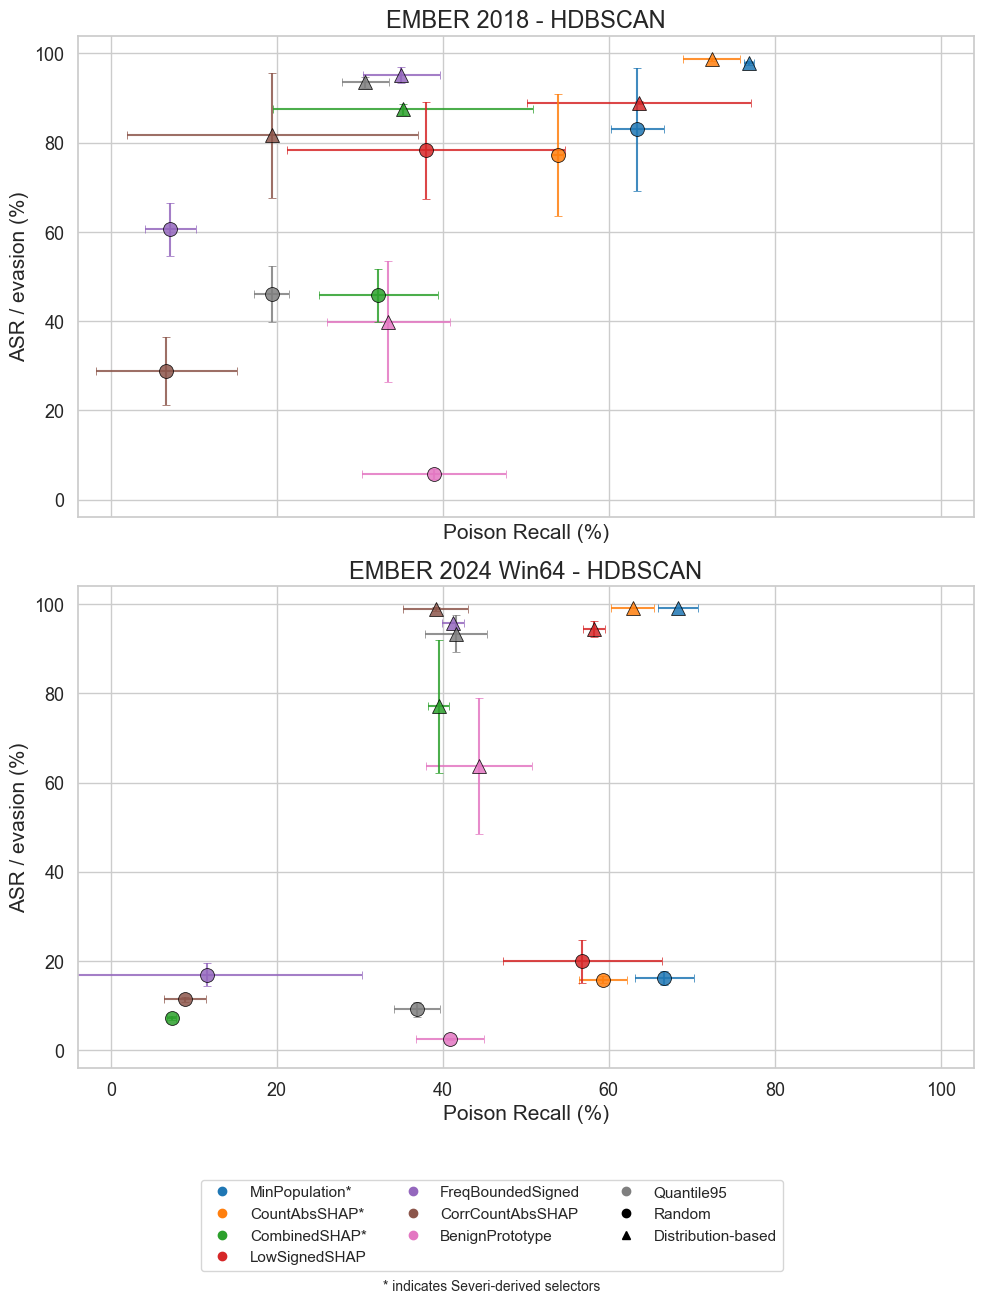

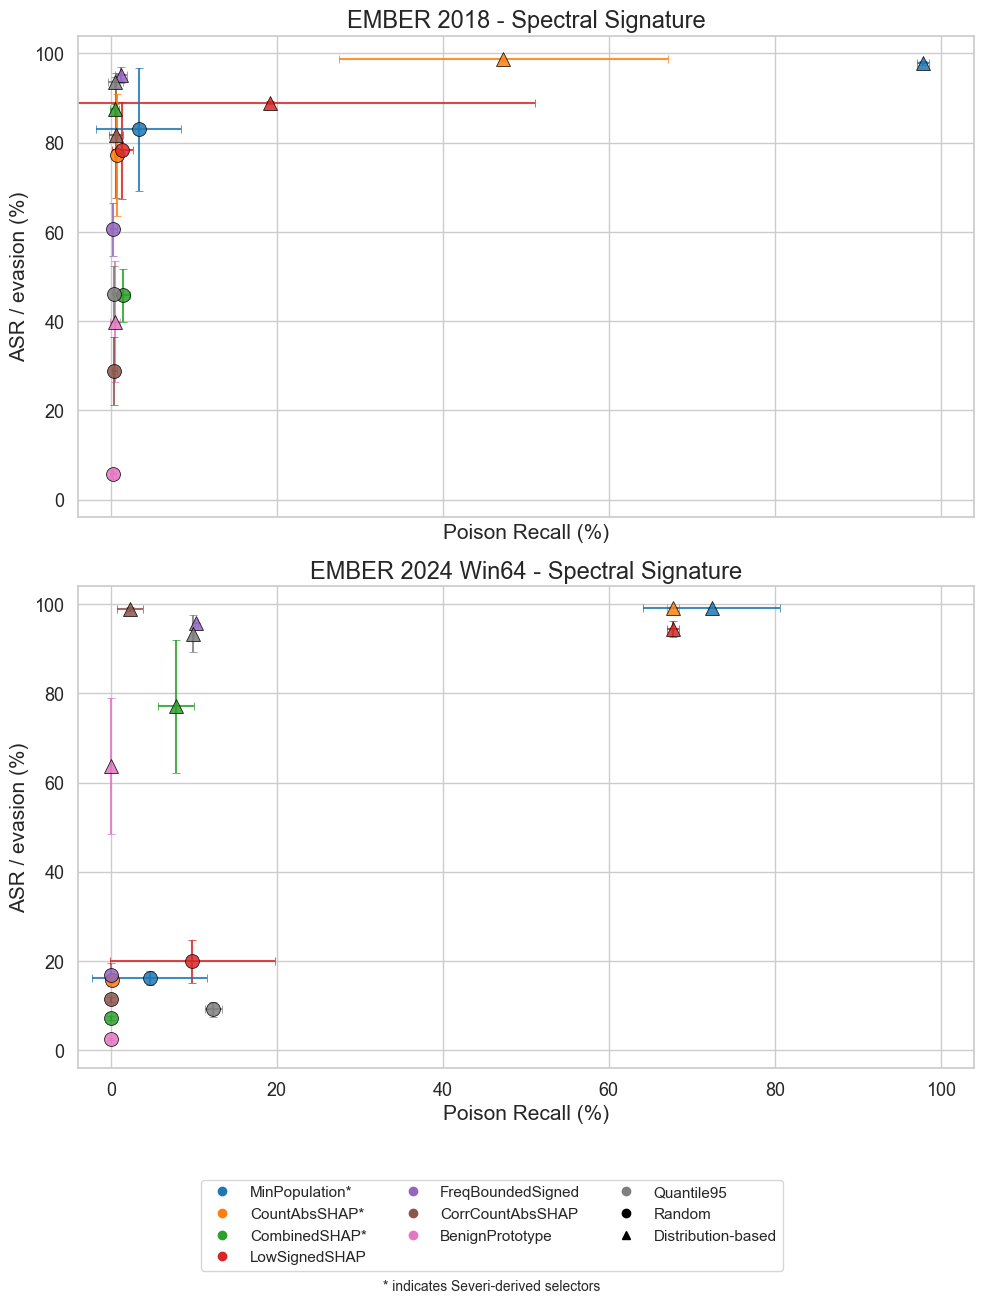

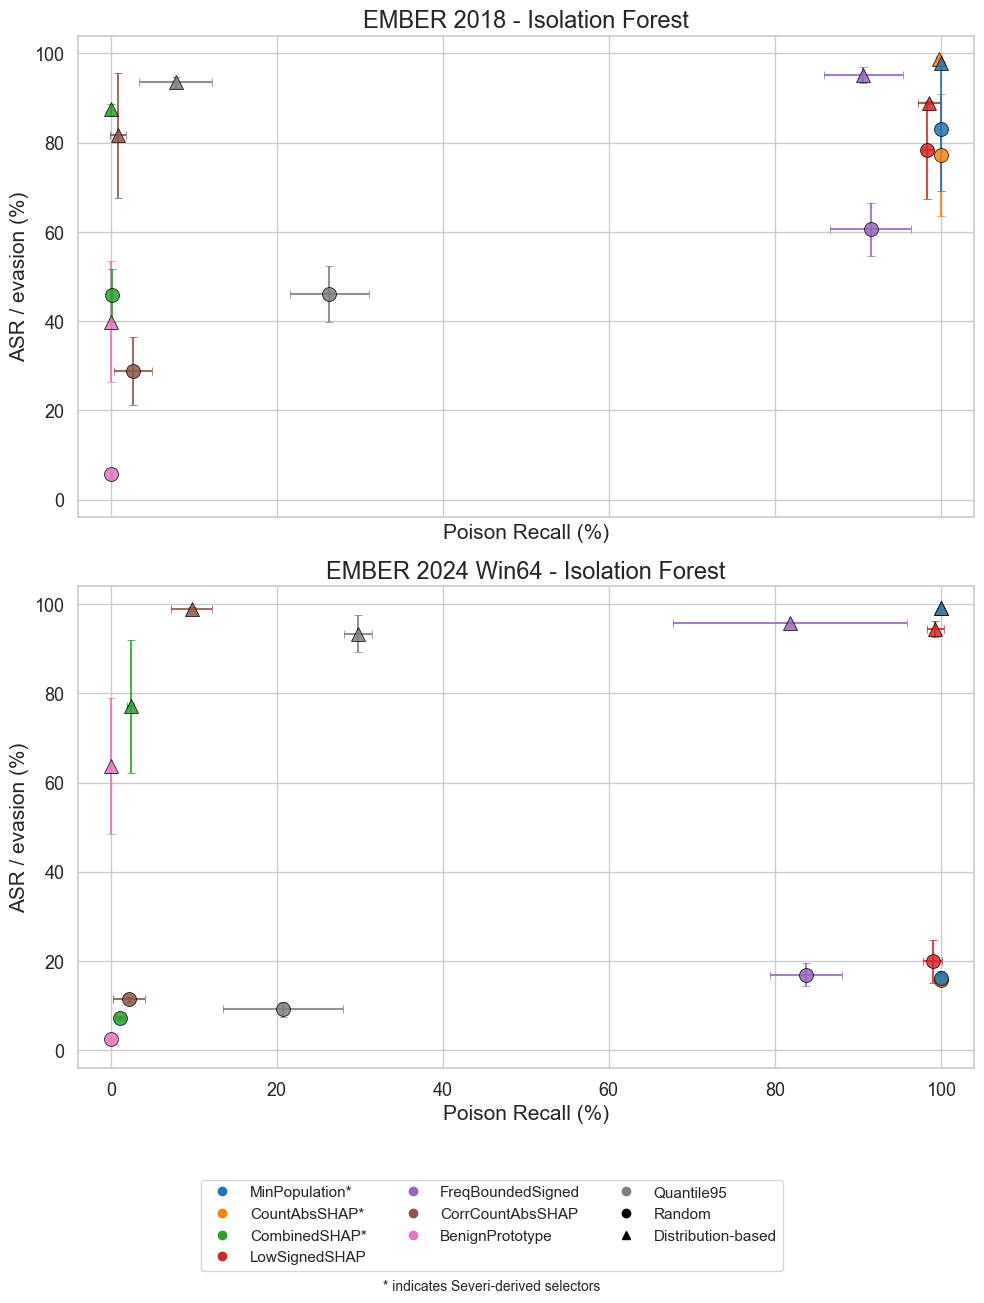

In [5]:
def save_figure(fig, stem):
    fig.savefig(PLOTS / f'{stem}.png', dpi=220, bbox_inches='tight')
    fig.savefig(PLOTS / f'{stem}.pdf', bbox_inches='tight')

legend_handles = [Line2D([], [], color=COLORS[s], marker='o', linestyle='', label=LABELS[s]) for s in SELECTORS]
legend_handles += [Line2D([], [], color='black', marker=m, linestyle='', label=s)
                   for s, m in [('Random', 'o'), ('Distribution-based', '^')]]
for method in METHODS:
    for show_sd in [True, False]:
        fig, axes = plt.subplots(2, 1, figsize=(10, 13), sharex=True, sharey=True)
        for ax, dataset in zip(axes, DATASETS):
            sub = mean_std[mean_std.dataset.eq(dataset)]
            for _, row in sub.iterrows():
                ax.errorbar(row[f'poison_recall_mean_{method}'], row.asr_mean,
                            xerr=row[f'poison_recall_std_{method}'] if show_sd else None,
                            yerr=row.asr_std if show_sd else None,
                            fmt='o' if row.sampling == 'Random' else '^',
                            color=COLORS[row.value_selector], markersize=10,
                            markeredgecolor='black', markeredgewidth=0.6, capsize=3, alpha=0.85)
            ax.set_title(f'{dataset} - {METHOD_LABELS[method]}', fontsize=17)
            ax.set_xlim(-4, 104); ax.set_ylim(-4, 104)
            ax.set_xlabel('Poison Recall (%)', fontsize=15)
            ax.set_ylabel('ASR / evasion (%)', fontsize=15)
            ax.tick_params(labelsize=13)
        fig.legend(handles=legend_handles, loc='lower center', bbox_to_anchor=(0.5, 0.01), ncol=3, fontsize=11)
        fig.text(0.5, 0.001, '* indicates Severi-derived selectors', ha='center', fontsize=10)
        fig.tight_layout(rect=[0, 0.115, 1, 1])
        save_figure(fig, f'asr_vs_{method}_recall_1p_three_seed_' + ('mean_std' if show_sd else 'mean'))
        if show_sd:
            plt.show()
        plt.close(fig)


## Figure: Direct ASR and Poison-Recall Comparisons

Two sampling panels per dataset and sanitizer. Selectors are ranked by mean ASR within each panel. Black numbers show means; error bars show sample standard deviation.


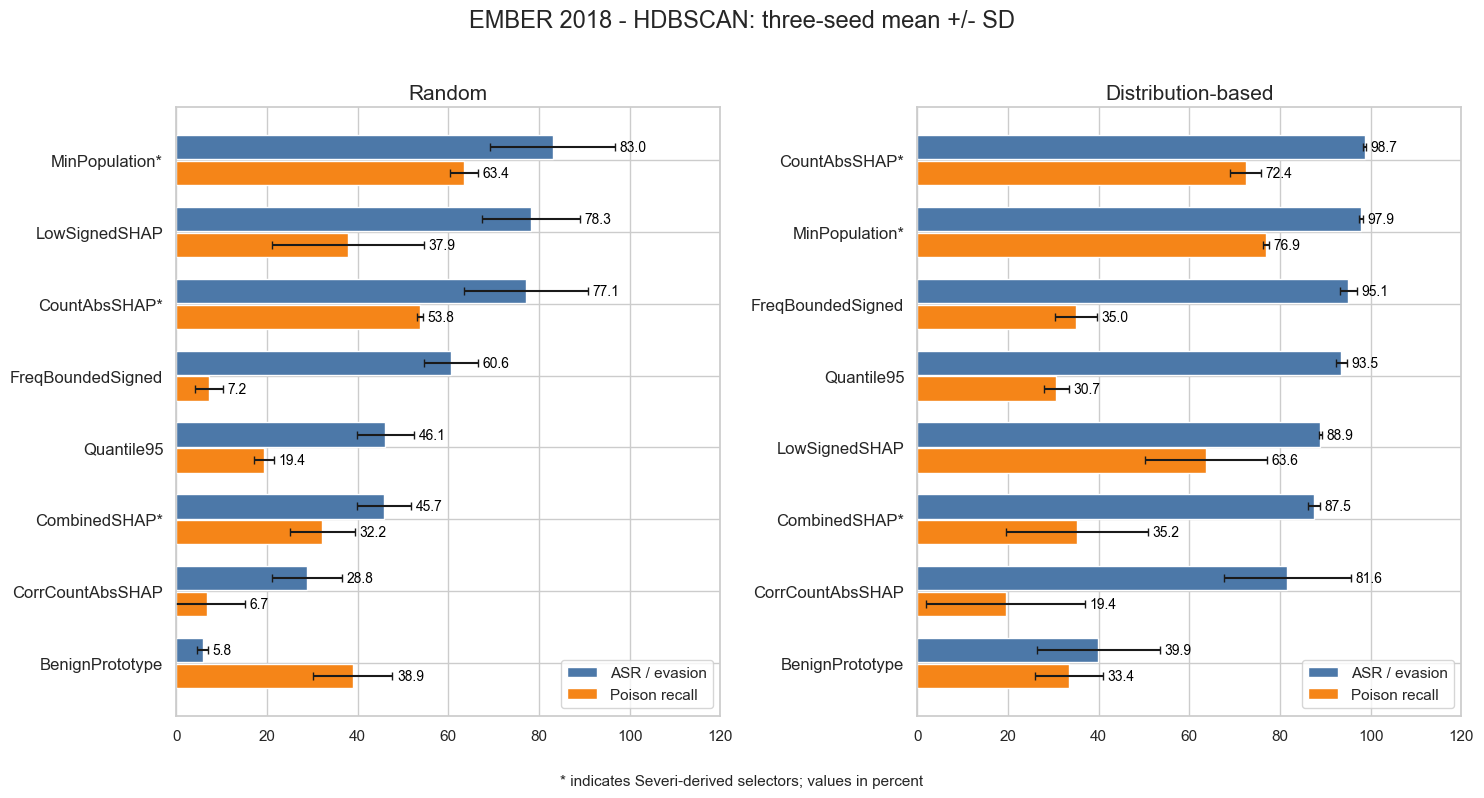

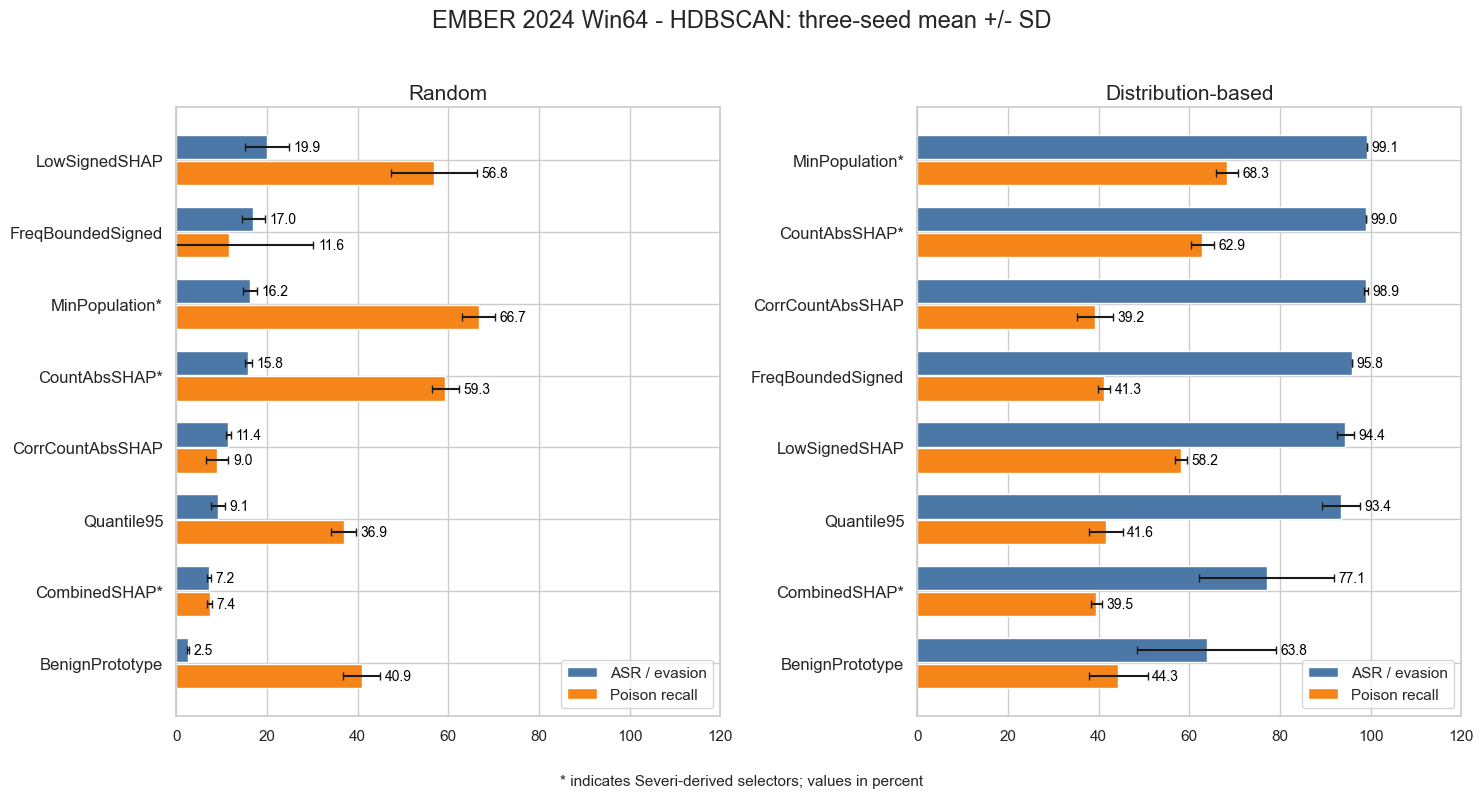

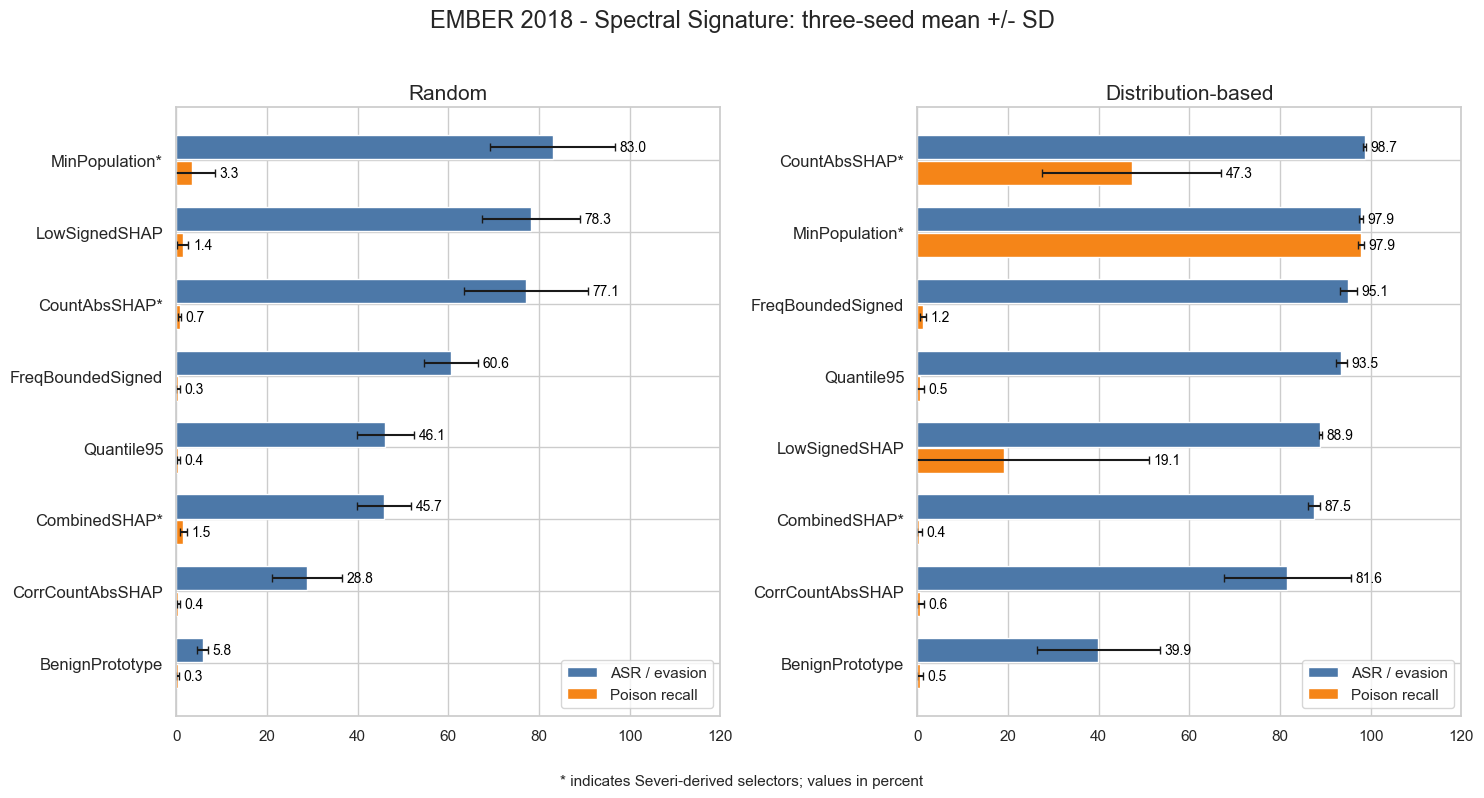

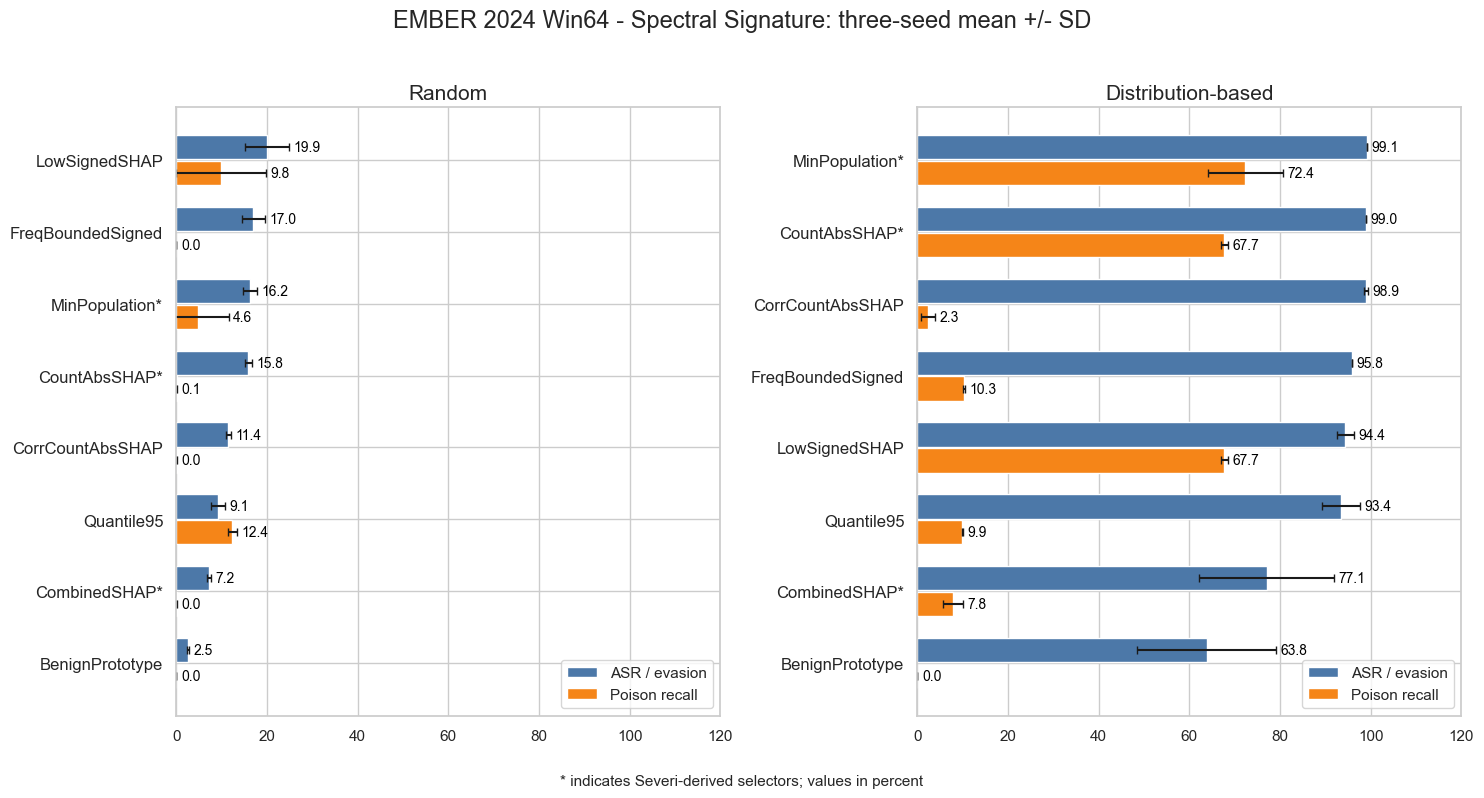

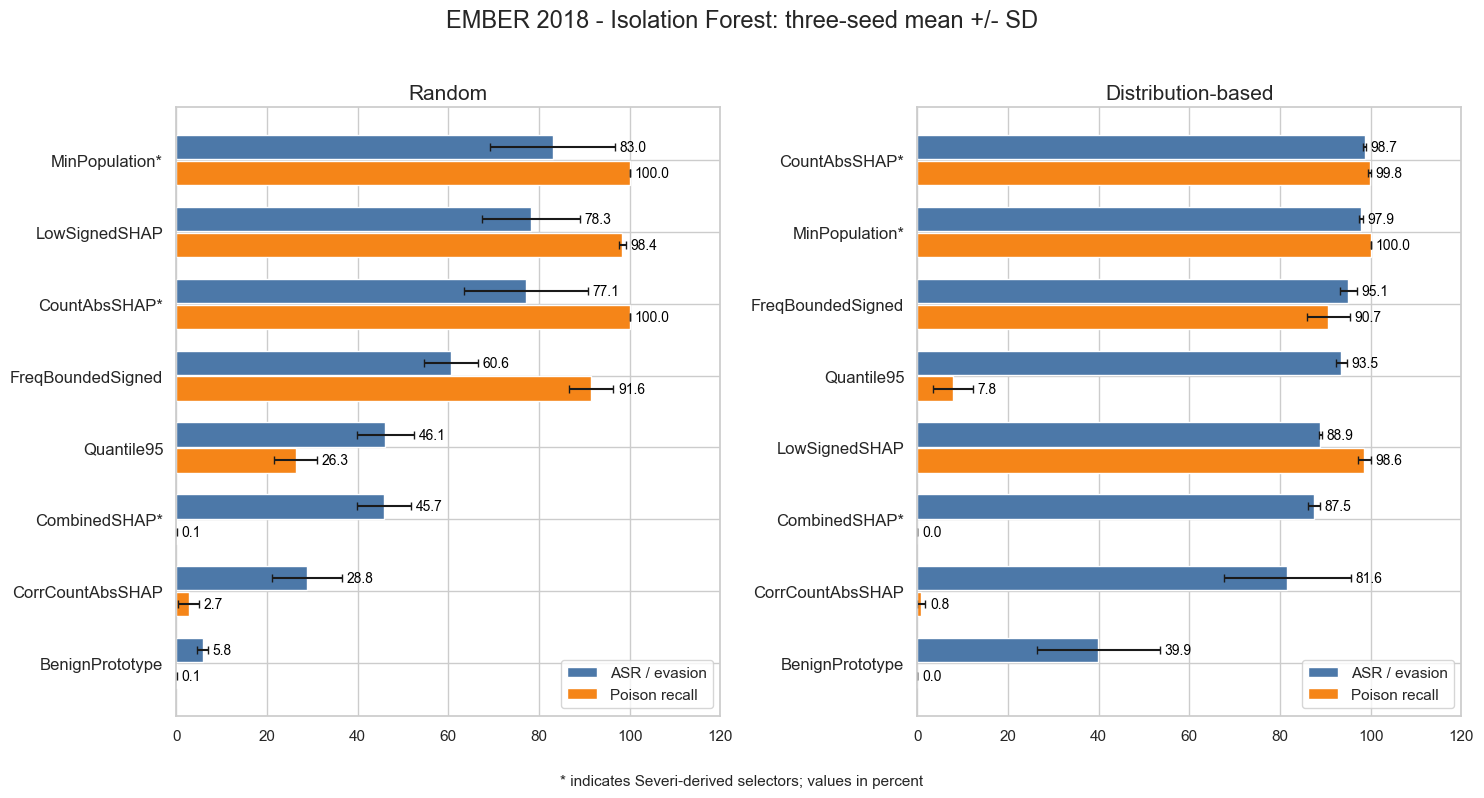

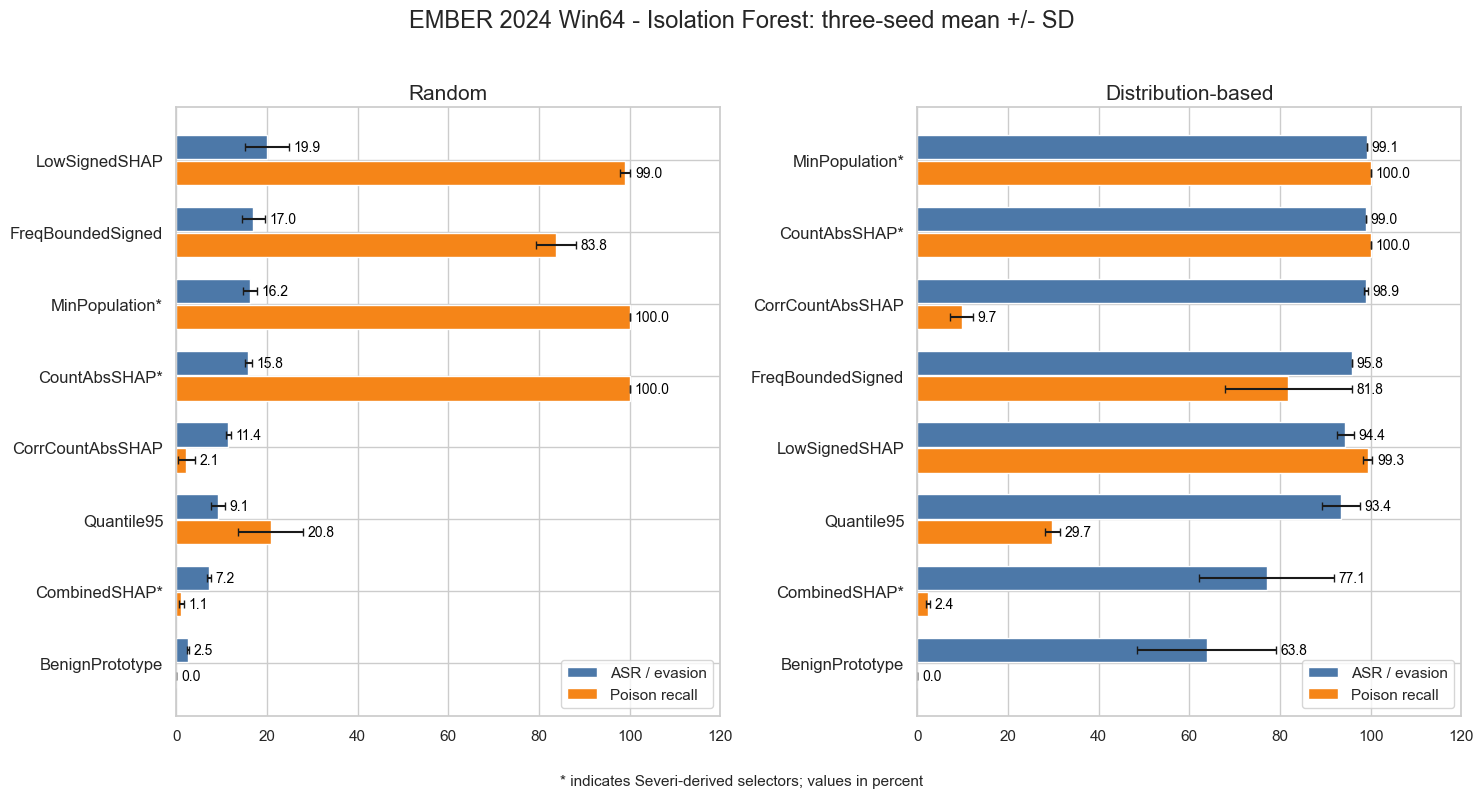

In [6]:
for method in METHODS:
    for dataset in DATASETS:
        fig, axes = plt.subplots(1, 2, figsize=(15, 8), sharex=True)
        for ax, sampling in zip(axes, ['Random', 'Distribution-based']):
            sub = mean_std[mean_std.dataset.eq(dataset) & mean_std.sampling.eq(sampling)].sort_values('asr_mean', ascending=False)
            y = np.arange(len(sub))
            for shift, metric, sd, color, label in [
                (-0.18, 'asr_mean', 'asr_std', '#4C78A8', 'ASR / evasion'),
                (0.18, f'poison_recall_mean_{method}', f'poison_recall_std_{method}', '#F58518', 'Poison recall')]:
                ax.barh(y + shift, sub[metric], height=0.34, xerr=sub[sd], capsize=3, color=color, label=label)
                for pos, value, deviation in zip(y + shift, sub[metric], sub[sd]):
                    ax.text(value + deviation + 1, pos, f'{value:.1f}', va='center', fontsize=10, color='black')
            ax.set_yticks(y, sub.selector, fontsize=12)
            ax.invert_yaxis(); ax.set_xlim(0, 120)
            ax.set_title(sampling, fontsize=15)
            ax.set_xlabel('')
            ax.legend(loc='lower right', fontsize=11)
        fig.suptitle(f'{dataset} - {METHOD_LABELS[method]}: three-seed mean +/- SD', fontsize=17)
        fig.text(0.5, 0.01, '* indicates Severi-derived selectors; values in percent', ha='center', fontsize=11)
        fig.tight_layout(rect=[0, 0.04, 1, 0.96])
        save_figure(fig, f"three_seed_bars_{dataset.replace(' ', '_').lower()}_{method}")
        plt.show(); plt.close(fig)


## Heatmap: Three-Seed Mean ASR / Evasion


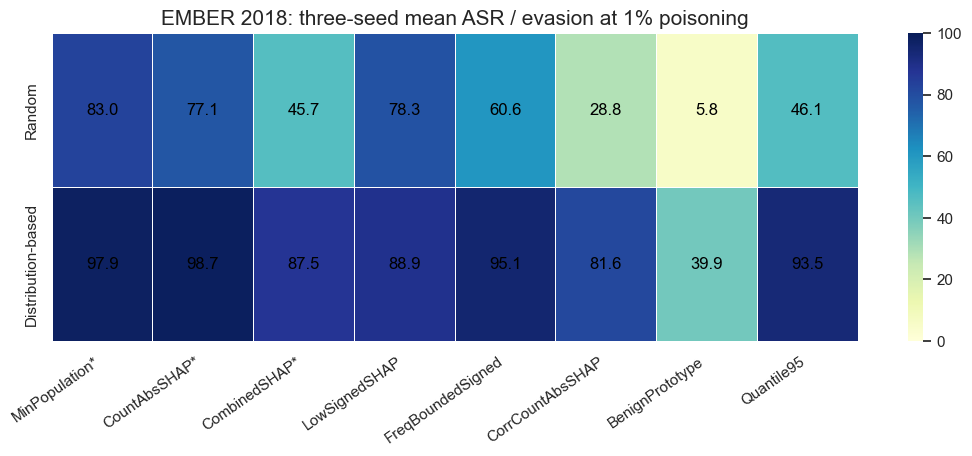

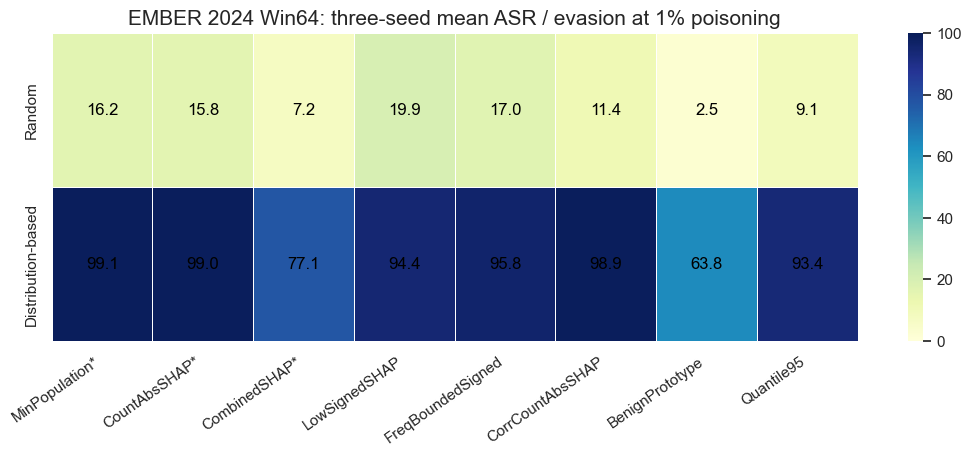

In [7]:
for dataset in DATASETS:
    sub = mean_std[mean_std.dataset.eq(dataset)]
    pivot = sub.pivot(index='sampling', columns='value_selector', values='asr_mean').reindex(index=['Random', 'Distribution-based'], columns=SELECTORS)
    fig, ax = plt.subplots(figsize=(13, 4))
    sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlGnBu', vmin=0, vmax=100,
                annot_kws={'color': 'black'}, linewidths=0.5, ax=ax)
    ax.set_title(f'{dataset}: three-seed mean ASR / evasion at 1% poisoning', fontsize=15)
    ax.set_xticklabels([LABELS[s] for s in SELECTORS], rotation=35, ha='right')
    ax.set_xlabel(''); ax.set_ylabel('')
    save_figure(fig, f"three_seed_asr_heatmap_{dataset.replace(' ', '_').lower()}")
    plt.show(); plt.close(fig)


## Downloads and Artifact Cleanup

All scalar snapshots and copied sanitizer settings below are outside `attack_artifacts`. After successful execution and coverage validation, large NPY inputs can be removed without breaking this notebook. Entire artifact folders can also be removed if no row-level analysis or retraining is needed: the snapshot fallback preserves these tables and figures. Keep the merged clean-model SHAP caches for future runs. No files are deleted by this notebook.


In [8]:
for path in sorted(OUT.glob('*.csv')):
    display(FileLink(str(path)))
display(FileLink(str(OUT / 'snapshot_manifest.json')))
print('Scalar results:', OUT)
print('PDF/PNG figures:', PLOTS)


/Users/falcon/Machine Learning/Defense GMM-Maha/results/experiment 1/tables/final_result_seed42_seed43_seed44/poison_1p/mean_std_ember_2018.csv

/Users/falcon/Machine Learning/Defense GMM-Maha/results/experiment 1/tables/final_result_seed42_seed43_seed44/poison_1p/mean_std_ember_2024_win64.csv

/Users/falcon/Machine Learning/Defense GMM-Maha/results/experiment 1/tables/final_result_seed42_seed43_seed44/poison_1p/seed_level_attack.csv

/Users/falcon/Machine Learning/Defense GMM-Maha/results/experiment 1/tables/final_result_seed42_seed43_seed44/poison_1p/seed_level_effectiveness_detectability.csv

/Users/falcon/Machine Learning/Defense GMM-Maha/results/experiment 1/tables/final_result_seed42_seed43_seed44/poison_1p/seed_level_sanitizers.csv

/Users/falcon/Machine Learning/Defense GMM-Maha/results/experiment 1/tables/final_result_seed42_seed43_seed44/poison_1p/three_seed_mean_std_effectiveness_detectability.csv

/Users/falcon/Machine Learning/Defense GMM-Maha/results/experiment 1/tables/final_result_seed42_seed43_seed44/poison_1p/three_seed_mean_std_sanitizers_long.csv

/Users/falcon/Machine Learning/Defense GMM-Maha/results/experiment 1/tables/final_result_seed42_seed43_seed44/poison_1p/snapshot_manifest.json

Scalar results: /Users/falcon/Machine Learning/Defense GMM-Maha/results/experiment 1/tables/final_result_seed42_seed43_seed44/poison_1p
PDF/PNG figures: /Users/falcon/Machine Learning/Defense GMM-Maha/results/experiment 1/plots/final_result_seed42_seed43_seed44/poison_1p
